In [ ]:
from pathlib import Path


def project_root() -> Path:
    """Resolve repo root (repo root, notebooks/, or other subfolders)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        km = d / "keras_models"
        if km.is_dir() and any(km.glob("*.keras")):
            return d
        if (d / ".git").exists() and (d / "results").is_dir():
            return d
    if (cwd / "datasets").is_dir() or (cwd / "results").is_dir():
        return cwd
    if (cwd.parent / "datasets").is_dir() or (cwd.parent / "results").is_dir():
        return cwd.parent
    return cwd


ROOT = project_root()


In [2]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import zipfile
import tempfile
import time
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Critical-difference visualization (aeon)
try:
    from aeon.visualisation import plot_critical_difference
except ImportError:
    print("aeon unavailable. Run `pip install aeon` in a terminal if needed.")

# ===================== Initial settings =====================
RESULTS_DIR = ROOT / "results"
KERAS_DIR = ROOT / "keras_models"
TFLITE_DIR = ROOT / "tflite_models"
WAKE_TFLITE_DIR = ROOT / "exports" / "wakevision" / "tflite_models"

MODEL_NAMES = ["MobileNetV3Small", "EfficientNetB0", "MCUNet_Official"]
DISPLAY_NAMES = {
    "MobileNetV3Small": "MobileNetV3-Small",
    "EfficientNetB0": "EfficientNet-B0",
    "MCUNet_Official": "MCUNet Official",
}

# Permite unificar nomes de models vindos de arquivos diferentes
MODEL_ALIASES = {
    "MCUNet": "MCUNet_Official",
    "MCUNet_Official": "MCUNet_Official",
    "MobileNetV3Small": "MobileNetV3Small",
    "EfficientNetB0": "EfficientNetB0",
}

SEVERITIES = [1, 2, 3, 4, 5]

def _load_jsonl(path: Path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows

def _load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

def err_from_acc(acc):
    return 1.0 - float(acc)


In [9]:
# =============================================================================
# 1. Load data: robustness (CE by corruption)
# =============================================================================

def get_corruption_errors(dataset_name, jsonl_path, baseline_acc_path):
    ce_results = _load_jsonl(jsonl_path)
    baseline_acc = _load_json(baseline_acc_path)
    corruptions_list = list(baseline_acc.keys())

    results_by_model = {name: {} for name in MODEL_NAMES}
    for r in ce_results:
        model_name = MODEL_ALIASES.get(r["model"], r["model"])
        if model_name in MODEL_NAMES:
            results_by_model[model_name][r["corruption"]] = r

    data = []
    for model in MODEL_NAMES:
        for c in corruptions_list:
            if c not in results_by_model[model]:
                continue
            r = results_by_model[model][c]
            base = baseline_acc[c]

            # CE = Σ_s err_model(s) / Σ_s err_baseline(s)
            num_err = sum(err_from_acc(r[f"acc_s{s}"]) for s in SEVERITIES)
            den_err = sum(err_from_acc(base[f"acc_s{s}"]) for s in SEVERITIES)
            ce = (num_err / den_err) * 100 if den_err > 0 else float("nan")

            data.append({
                "Dataset": dataset_name,
                "Model": model,
                "Corruption": c,
                "CE": ce
            })
    return data

# Extracting for CIFAR-10-C, CIFAR-100-C, and Wake Vision
c10_data = get_corruption_errors(
    "CIFAR10",
    RESULTS_DIR / "cifar10c_baseline-MCUNet_Official_ce_results.jsonl",
    RESULTS_DIR / "cifar10c_baseline-MCUNet_Official_baseline_acc.json"
)
c100_data = get_corruption_errors(
    "CIFAR100",
    RESULTS_DIR / "cifar100c_baseline-MCUNet_Official_ce_results.jsonl",
    RESULTS_DIR / "cifar100c_baseline-MCUNet_Official_baseline_acc.json"
)
wake_data = get_corruption_errors(
    "WakeVision",
    RESULTS_DIR / "wakevision_baseline-MCUNet_ce_results.jsonl",
    RESULTS_DIR / "wakevision_baseline-MCUNet_baseline_acc.json"
)

df_ce = pd.DataFrame(c10_data + c100_data + wake_data)
print("Amostra dos Dados de Robustez (CE):")
display(df_ce.head())

Amostra dos Dados de Robustez (CE):


,Dataset,Model,Corruption,CE
0,CIFAR10,MobileNetV3Small,brightness,32.918345
1,CIFAR10,MobileNetV3Small,contrast,74.596397
2,CIFAR10,MobileNetV3Small,defocus_blur,48.789547
3,CIFAR10,MobileNetV3Small,elastic_transform,57.404988
4,CIFAR10,MobileNetV3Small,fog,77.559234


In [10]:
# =============================================================================
# 2. Load/Processar Dados: LATÊNCIA
# =============================================================================

TFLITE_FILES = {
    "CIFAR10": {
        "MobileNetV3Small": "MobileNetV3Small_CIFAR10.tflite",
        "EfficientNetB0":   "EfficientNetB0_CIFAR10.tflite",
        "MCUNet_Official":  "MCUNet_Official_CIFAR10.tflite",
    },
    "CIFAR100": {
        "MobileNetV3Small": "MobileNetV3Small_CIFAR100.tflite",
        "EfficientNetB0":   "EfficientNetB0_CIFAR100.tflite",
        "MCUNet_Official":  "MCUNet_Official_CIFAR100.tflite",
    },
    "WakeVision": {
        "MobileNetV3Small": "MobileNetV3Small_wake_vision.tflite",
        "EfficientNetB0":   "EfficientNetB0_wake_vision.tflite",
        "MCUNet_Official":  "MCUNet_wake_vision.tflite",
    },
}

TFLITE_DIRS = {
    "CIFAR10": TFLITE_DIR,
    "CIFAR100": TFLITE_DIR,
    "WakeVision": WAKE_TFLITE_DIR if WAKE_TFLITE_DIR.exists() else TFLITE_DIR,
}

def get_latencies(dataset_name, num_warmup=10, num_runs=100):
    data = []
    dataset_tflite_dir = TFLITE_DIRS[dataset_name]
    for model in MODEL_NAMES:
        tflite_path = dataset_tflite_dir / TFLITE_FILES[dataset_name][model]
        if not tflite_path.exists():
            continue
            
        interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
        interpreter.allocate_tensors()
        inp = interpreter.get_input_details()[0]
        dummy = np.random.uniform(0, 255, size=inp['shape']).astype(np.float32)

        # Warmup
        for _ in range(num_warmup):
            interpreter.set_tensor(inp['index'], dummy)
            interpreter.invoke()

        # Medições
        for i in range(num_runs):
            t0 = time.perf_counter()
            interpreter.set_tensor(inp['index'], dummy)
            interpreter.invoke()
            t1 = time.perf_counter()
            
            data.append({
                "Dataset": dataset_name,
                "Model": model,
                "Run": i,
                "Latency_ms": (t1 - t0) * 1000
            })
    return data

lat_c10 = get_latencies("CIFAR10")
lat_c100 = get_latencies("CIFAR100")
lat_wake = get_latencies("WakeVision")

df_latency = pd.DataFrame(lat_c10 + lat_c100 + lat_wake)
print("Latency data sample:")
display(df_latency.head())

C:/home/anonymous/project/Lightweight Analyses/project/Lightweight Analyses\project\Lightweight Analyses\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Amostra dos Dados de Latency:


,Dataset,Model,Run,Latency_ms
0,CIFAR10,MobileNetV3Small,0,3.0609
1,CIFAR10,MobileNetV3Small,1,1.0289
2,CIFAR10,MobileNetV3Small,2,0.8981
3,CIFAR10,MobileNetV3Small,3,0.8323
4,CIFAR10,MobileNetV3Small,4,0.7664


In [4]:
# =============================================================================
# 3. Statistical functions (Friedman / critical difference)
# =============================================================================

def rank_metric(df, index_cols, columns, values, ascending=True):
    """
    Ranks the values for each block (index_cols) across treatments (columns).
    """
    pivot = df.pivot_table(index=index_cols, columns=columns, values=values)
    ranked = pivot.rank(axis=1, ascending=ascending)
    return pivot, ranked

def friedman_test(df_ranked, metric_name):
    # Extract the data as a list of arrays (one for each treatment)
    data = [df_ranked[column].dropna().values for column in df_ranked.columns]
    
    # Perform the Friedman test
    friedman_result = stats.friedmanchisquare(*data)

    print(f"Friedman test for {metric_name}")
    print(f"Statistic: {friedman_result.statistic:.4f}")
    print(f"p-value: {friedman_result.pvalue:.4e}")
    return friedman_result

def generate_critical_difference(df_ranked, output_pdf, plot_title, lower_better=True, test='nemenyi'):
    scores = df_ranked.values
    classifiers = df_ranked.columns.tolist()
    
    # Check if we have NaN values. Nemenyi test requires complete blocks usually.
    if np.isnan(scores).any():
        print("Warning: NaNs in ranks. Dropping incomplete rows for the CD plot.")
        df_ranked = df_ranked.dropna()
        scores = df_ranked.values
    
    # Display names mapped to classifiers
    mapped_classifiers = [DISPLAY_NAMES.get(c, c) for c in classifiers]
    
    plot_critical_difference(
        scores,
        mapped_classifiers,
        lower_better=lower_better,
        test=test, 
        correction='holm', 
    )

    ax = plt.gca()
    ax.set_title(plot_title)

    # Margins and label spaces
    plt.subplots_adjust(bottom=0.35)
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight", dpi=300)
    plt.show()

--- TESTE FRIEDMAN PARA ROBUSTNESS (CE) ---


Model                      EfficientNetB0  MCUNet_Official  MobileNetV3Small
Dataset Corruption                                                          
CIFAR10 brightness                    1.0              3.0               2.0
        contrast                      1.0              3.0               2.0
        defocus_blur                  1.0              3.0               2.0
        elastic_transform             1.0              3.0               2.0
        fog                           1.0              3.0               2.0

Friedman test for Corruption Error (CE)
Statistic: 104.4561
p-value: 2.0780e-23

Generating critical-difference diagram for robustness...


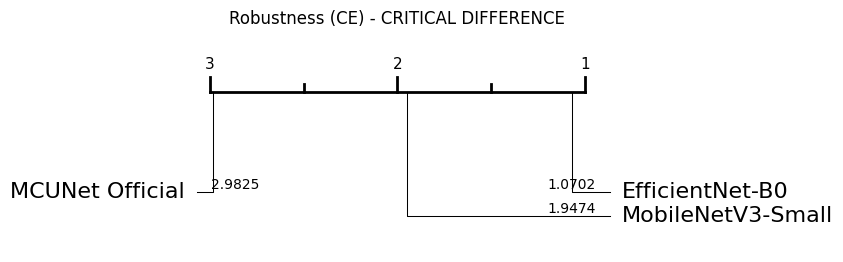

In [12]:
# =============================================================================
# 4. Tests for robustness (corruption error)
# =============================================================================
# Here treatments are the models, and blocks are (dataset, corruption) pairs.
print("--- TESTE FRIEDMAN PARA ROBUSTNESS (CE) ---")
# lower is better (ascending = True)
df_ce_pivot, df_ce_ranked = rank_metric(
    df_ce, 
    index_cols=['Dataset', 'Corruption'], 
    columns='Model', 
    values='CE', 
    ascending=True
)

display(df_ce_ranked.head())
friedman_test(df_ce_ranked, "Corruption Error (CE)")

print("\nGenerating critical-difference diagram for robustness...")
generate_critical_difference(
    df_ce_ranked, 
    ROOT / "figures" / "cd_robustness_ce.pdf", 
    'Robustness (CE) - CRITICAL DIFFERENCE', 
    lower_better=True, 
    test='nemenyi'
)

--- TESTE FRIEDMAN PARA LATÊNCIA ---


Model        EfficientNetB0  MCUNet_Official  MobileNetV3Small
Dataset Run                                                   
CIFAR10 0               2.0              3.0               1.0
        1               2.0              3.0               1.0
        2               3.0              2.0               1.0
        3               2.0              3.0               1.0
        4               2.0              3.0               1.0

Friedman test for Latency (ms)
Statistic: 465.3600
p-value: 8.8789e-102

Generating critical-difference diagram for latency...


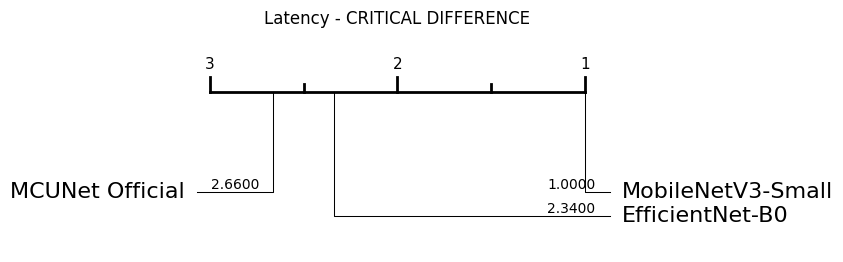

In [13]:
# =============================================================================
# 5. Tests for latency
# =============================================================================
# Here treatments are models, and blocks are run groups per dataset.
# Com 100 runs por dataset e 3 datasets (CIFAR10, CIFAR100 e WakeVision), temos até 300 blocos.
print("--- TESTE FRIEDMAN PARA LATÊNCIA ---")
# lower is better (ascending = True)
df_lat_pivot, df_lat_ranked = rank_metric(
    df_latency, 
    index_cols=['Dataset', 'Run'], 
    columns='Model', 
    values='Latency_ms', 
    ascending=True
)

display(df_lat_ranked.head())
friedman_test(df_lat_ranked, "Latency (ms)")

print("\nGenerating critical-difference diagram for latency...")
generate_critical_difference(
    df_lat_ranked, 
    ROOT / "figures" / "cd_latency.pdf", 
    'Latency - CRITICAL DIFFERENCE', 
    lower_better=True, 
    test='nemenyi'
)

In [14]:
# =============================================================================
# 6. Testes para Tamanho (Size)
# =============================================================================
# O tamanho do model é determinístico e não possui variância num mesmo pipeline.
# Aqui usamos os datasets CIFAR-10, CIFAR-100 e Wake Vision para uma comparação descritiva.

def compute_sizes(dataset_name):
    data = []
    dataset_tflite_dir = TFLITE_DIRS[dataset_name]
    
    def get_size(path):
        return Path(path).stat().st_size / (1024 * 1024) if Path(path).exists() else float('nan')
        
    for model in MODEL_NAMES:
        tflite_path = dataset_tflite_dir / TFLITE_FILES[dataset_name][model]
        ts = get_size(tflite_path)
        data.append({
            "Dataset": dataset_name,
            "Model": model,
            "TFLite_Size_MB": ts
        })
    return data

size_data = compute_sizes("CIFAR10") + compute_sizes("CIFAR100") + compute_sizes("WakeVision")
df_size = pd.DataFrame(size_data)

print("--- RANQUEAMENTO PARA TAMANHO DO MODELO (TFLite MB) ---")
df_size_pivot, df_size_ranked = rank_metric(
    df_size, 
    index_cols=['Dataset'], 
    columns='Model', 
    values='TFLite_Size_MB', 
    ascending=True # Menor tamanho é melhor
)

print("\nTamanho (MB):")
display(df_size_pivot)
print("\nRanques (1 = Menor/Melhor):")
display(df_size_ranked)

--- RANQUEAMENTO PARA TAMANHO DO MODELO (TFLite MB) ---

Tamanho (MB):


Model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
Dataset,,,
CIFAR10,15.346325,5.386055,3.579590
CIFAR100,15.786594,5.496407,3.777969
WakeVision,15.334347,5.398678,3.591373



Ranques (1 = Menor/Melhor):


Model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
Dataset,,,
CIFAR10,3.0,2.0,1.0
CIFAR100,3.0,2.0,1.0
WakeVision,3.0,2.0,1.0


--- RANQUEAMENTO PARA LATÊNCIA P90 (MOBILE) ---


Model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
Dataset,,,
CIFAR-10,14.595996,6.831000,1.672925
CIFAR-100,14.552039,6.847309,1.703297
WakeVision,27.622523,13.190808,3.146125



Ranques (1 = Menor/Melhor):


Model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
Dataset,,,
CIFAR-10,3.0,2.0,1.0
CIFAR-100,3.0,2.0,1.0
WakeVision,3.0,2.0,1.0


Friedman test for Mobile P90 Latency
Statistic: 6.0000
p-value: 4.9787e-02

Generating critical-difference diagram for latency P90 (Mobile)...


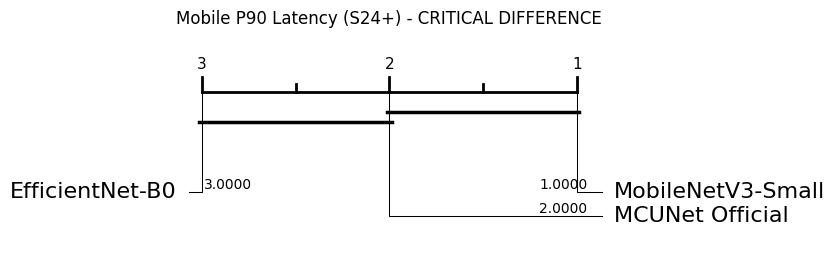


--- RANQUEAMENTO PARA THROUGHPUT (MOBILE) ---

Ranques (1 = Maior/Melhor):


Model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
Dataset,,,
CIFAR-10,3.0,2.0,1.0
CIFAR-100,3.0,2.0,1.0
WakeVision,3.0,2.0,1.0



Gerando CD Diagram para Throughput (Mobile)...


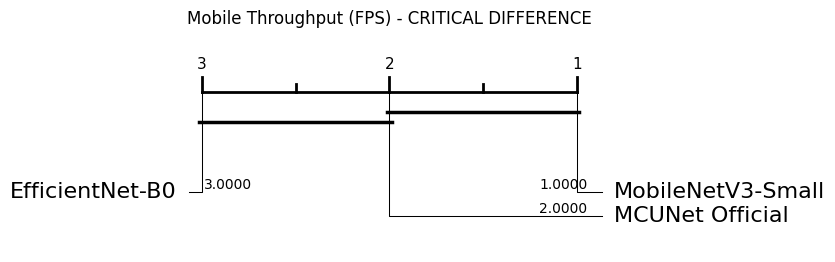

In [5]:
# =============================================================================
# 7. Testes Estatísticos para as Métricas do Celular (reference mobile device)
# =============================================================================
# Abaixo importamos os dados reais do celular para gerar um CD Diagram.

json_files_mobile = [
    'results/metrics_cifar10_cpu_500imgs_1774374564329.json',
    'results/metrics_cifar100_cpu_500imgs_1774374594031.json',
    'results/metrics_wakevision_cpu_500imgs_1774374640648.json'
]

mobile_data = []
for file in json_files_mobile:
    if os.path.exists(file):
        with open(file, 'r', encoding='utf-8') as f:
            content = json.load(f)
            for model in content['models']:
                # Padronizar nomes para o mesmo padrão usado em MODEL_NAMES
                base_model = model['modelName']
                if "EfficientNet" in base_model: 
                    base_model = "EfficientNetB0"
                elif "MCUNet" in base_model: 
                    base_model = "MCUNet_Official"
                elif "MobileNet" in base_model: 
                    base_model = "MobileNetV3Small"

                mobile_data.append({
                    "Dataset": model['datasetName'],
                    "Model": base_model,
                    "P90_Latency_ms": model['p90LatencyMs'],
                    "Throughput_FPS": model['throughputImagesPerSecond'],
                    "Accuracy": model['accuracy']
                })

df_mobile = pd.DataFrame(mobile_data)

# ---- 7.1 Teste para Latency P90 no Mobile ----
print("--- RANQUEAMENTO PARA LATÊNCIA P90 (MOBILE) ---")
# Menor latência é melhor (ascending=True)
df_mob_lat_pivot, df_mob_lat_ranked = rank_metric(
    df_mobile, 
    index_cols=['Dataset'], 
    columns='Model', 
    values='P90_Latency_ms', 
    ascending=True 
)

display(df_mob_lat_pivot)
print("\nRanques (1 = Menor/Melhor):")
display(df_mob_lat_ranked)

try:
    friedman_test(df_mob_lat_ranked, "Mobile P90 Latency")
except Exception as e:
    print(f"Aviso no test de Friedman: {e}")

print("\nGenerating critical-difference diagram for latency P90 (Mobile)...")
generate_critical_difference(
    df_mob_lat_ranked, 
    ROOT / "figures" / "cd_mobile_p90_latency.pdf", 
    'Mobile P90 Latency (S24+) - CRITICAL DIFFERENCE', 
    lower_better=True, 
    test='nemenyi'
)

# ---- 7.2 Teste para Throughput no Mobile ----
print("\n--- RANQUEAMENTO PARA THROUGHPUT (MOBILE) ---")
# Maior throughput é melhor (ascending=False)
df_mob_thr_pivot, df_mob_thr_ranked = rank_metric(
    df_mobile, 
    index_cols=['Dataset'], 
    columns='Model', 
    values='Throughput_FPS', 
    ascending=False 
)

print("\nRanques (1 = Maior/Melhor):")
display(df_mob_thr_ranked)

print("\nGerando CD Diagram para Throughput (Mobile)...")
generate_critical_difference(
    df_mob_thr_ranked, 
    ROOT / "figures" / "cd_mobile_throughput.pdf", 
    'Mobile Throughput (FPS) - CRITICAL DIFFERENCE', 
    lower_better=True, # no CD diagram, costuma-se usar "lower_better=True" para o rank (rank 1 é "menor/melhor").
    test='nemenyi'
)
